In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv(r"C:\Users\ASUS\Downloads\archive (4)\auto-mpg.csv")

In [3]:
print(df.head())

    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (398, 9)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [6]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [7]:
print(df.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
print(df.columns)

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')


In [10]:
print(df.dtypes)

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object


In [11]:
df['horsepower'] = pd.to_numeric(
    df['horsepower'],
    errors='coerce'
)

In [12]:
df['horsepower']

0      130.0
1      165.0
2      150.0
3      150.0
4      140.0
       ...  
393     86.0
394     52.0
395     84.0
396     79.0
397     82.0
Name: horsepower, Length: 398, dtype: float64

In [13]:
print(df.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


In [14]:
df['horsepower'].fillna(
    df['horsepower'].median(),
    inplace=True
)

In [15]:
print(df.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


In [16]:
df.drop('car name', axis=1, inplace=True)

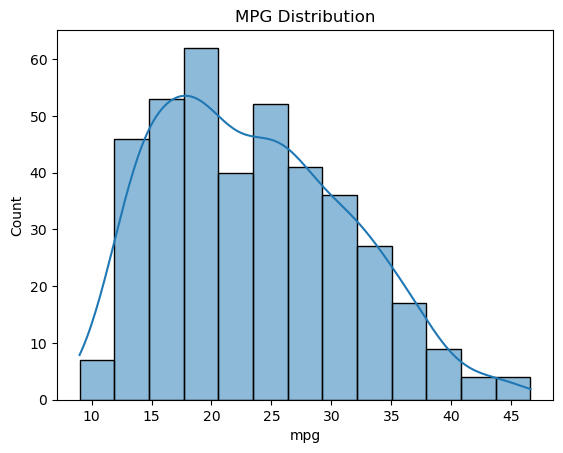

In [17]:
sns.histplot(df['mpg'], kde=True)

plt.title('MPG Distribution')

plt.show()

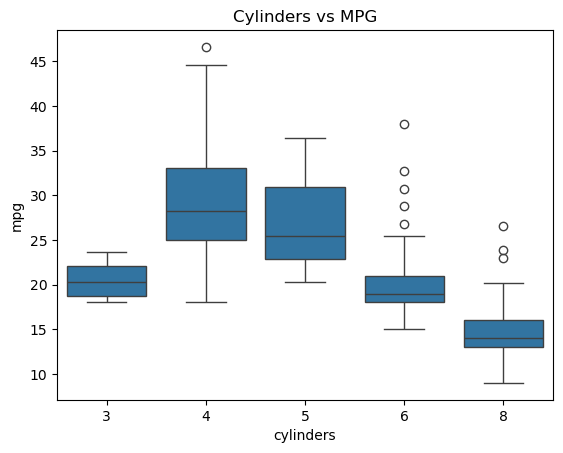

In [18]:
sns.boxplot(x='cylinders', y='mpg', data=df)

plt.title('Cylinders vs MPG')

plt.show()

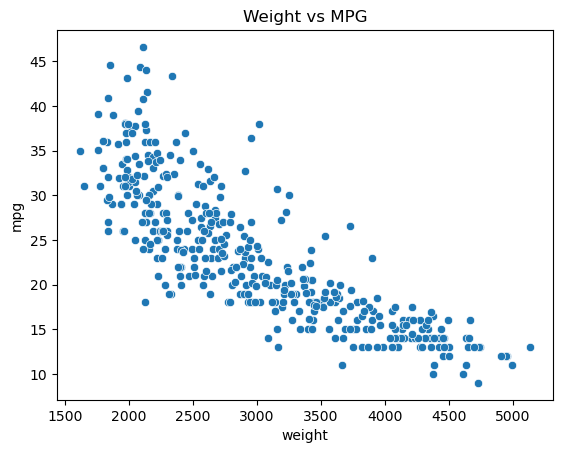

In [19]:
sns.scatterplot(x='weight', y='mpg', data=df)

plt.title('Weight vs MPG')

plt.show()

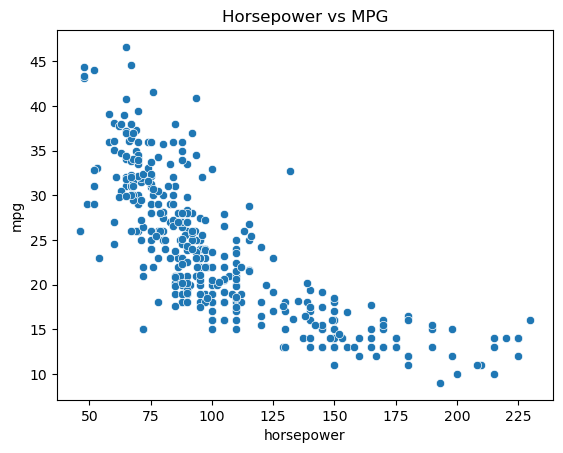

In [20]:
sns.scatterplot(x='horsepower', y='mpg', data=df)

plt.title('Horsepower vs MPG')

plt.show()

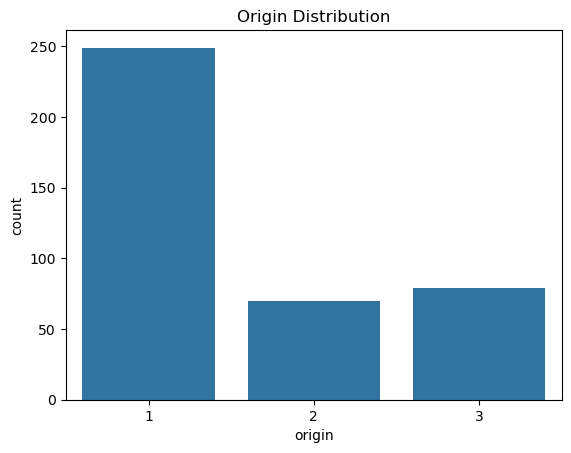

In [21]:
sns.countplot(x='origin', data=df)

plt.title('Origin Distribution')

plt.show()

In [22]:
corr_matrix = df.corr()

print(corr_matrix)

                   mpg  cylinders  displacement  horsepower    weight  \
mpg           1.000000  -0.775396     -0.804203   -0.773453 -0.831741   
cylinders    -0.775396   1.000000      0.950721    0.841284  0.896017   
displacement -0.804203   0.950721      1.000000    0.895778  0.932824   
horsepower   -0.773453   0.841284      0.895778    1.000000  0.862442   
weight       -0.831741   0.896017      0.932824    0.862442  1.000000   
acceleration  0.420289  -0.505419     -0.543684   -0.686590 -0.417457   
model year    0.579267  -0.348746     -0.370164   -0.413733 -0.306564   
origin        0.563450  -0.562543     -0.609409   -0.452096 -0.581024   

              acceleration  model year    origin  
mpg               0.420289    0.579267  0.563450  
cylinders        -0.505419   -0.348746 -0.562543  
displacement     -0.543684   -0.370164 -0.609409  
horsepower       -0.686590   -0.413733 -0.452096  
weight           -0.417457   -0.306564 -0.581024  
acceleration      1.000000    0.2881

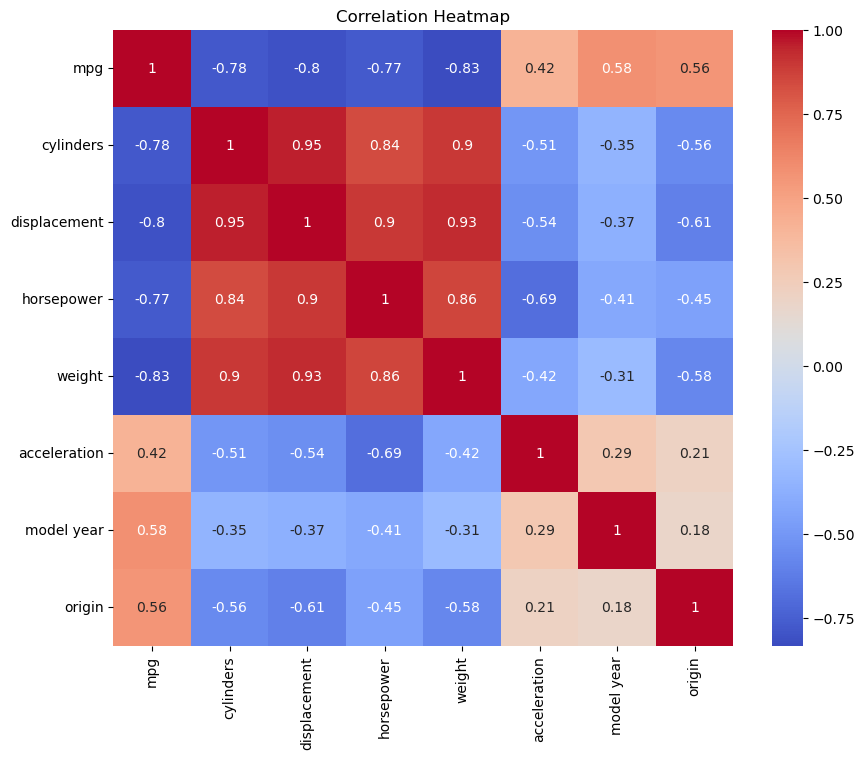

In [23]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [24]:
X = df.drop('mpg', axis=1)

y = df['mpg']

In [25]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [26]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled,
    y,
    test_size=0.30,
    random_state=42
)

In [27]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [28]:
print("Training Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (278, 7)
Validation Shape: (60, 7)
Testing Shape: (60, 7)


In [29]:
model = Sequential()
model.add(Dense(
    64,
    activation='relu',
    input_dim=X_train.shape[1]
))
model.add(Dropout(0.3))
model.add(Dense(
    32,
    activation='relu'
))
model.add(Dropout(0.3))
model.add(Dense(
    16,
    activation='relu'
))
model.add(Dense(1))

C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [33]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 585.1632 - mae: 22.8468 - val_loss: 564.3743 - val_mae: 22.6757
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 533.7190 - mae: 21.6354 - val_loss: 494.5951 - val_mae: 21.0802
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 441.4040 - mae: 19.4678 - val_loss: 371.0721 - val_mae: 18.0049
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 305.0691 - mae: 15.5175 - val_loss: 195.9988 - val_mae: 12.8107
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 143.9504 - mae: 10.3206 - val_loss: 51.8211 - val_mae: 5.9998
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 60.5840 - mae: 6.3056 - val_loss: 29.3005 - val_mae: 4.5961
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 48.7278 - mae: 5.5835 - val_loss: 22.7068 - val_mae: 4.0211
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 51.5849 - mae: 5.7067 - val_loss: 19.4685 - val_mae: 3.7310
Epoch 9/100
18/18 ━━━━━━━━━━━

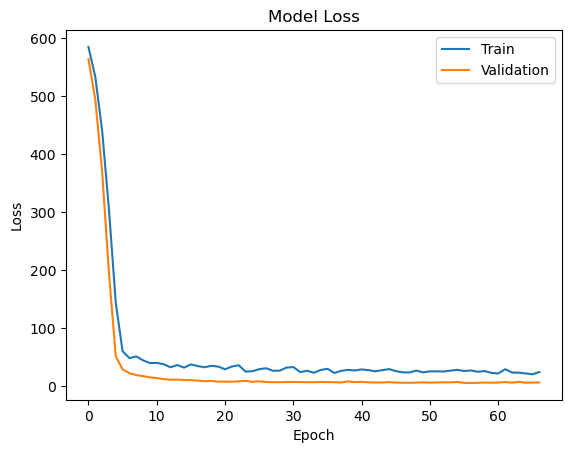

In [34]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

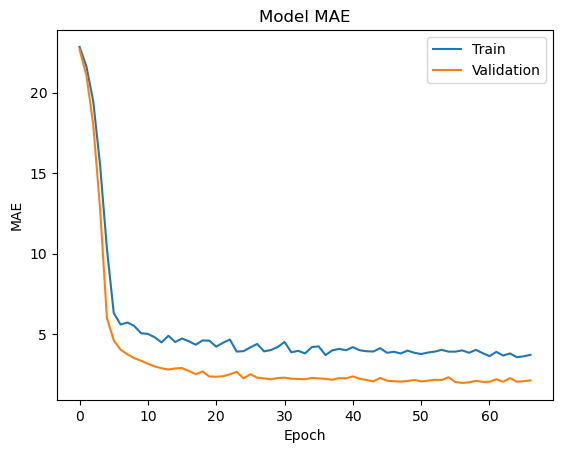

In [35]:
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])

plt.title('Model MAE')

plt.xlabel('Epoch')
plt.ylabel('MAE')

plt.legend(['Train', 'Validation'])

plt.show()

In [36]:
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [37]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 2.074671688079834


In [38]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 7.6348432934362735


In [39]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 2.763122019281138


In [40]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.8837922216039346


In [41]:
print("Model Performance")
print("------------------")

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

Model Performance
------------------
MAE : 2.074671688079834
MSE : 7.6348432934362735
RMSE: 2.763122019281138
R2  : 0.8837922216039346


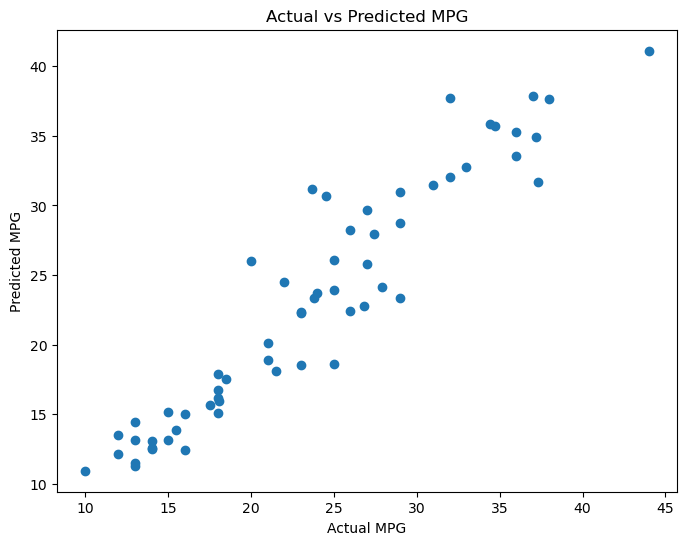

In [42]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")

plt.title("Actual vs Predicted MPG")

plt.show()

In [43]:
residuals = y_test - y_pred.flatten()

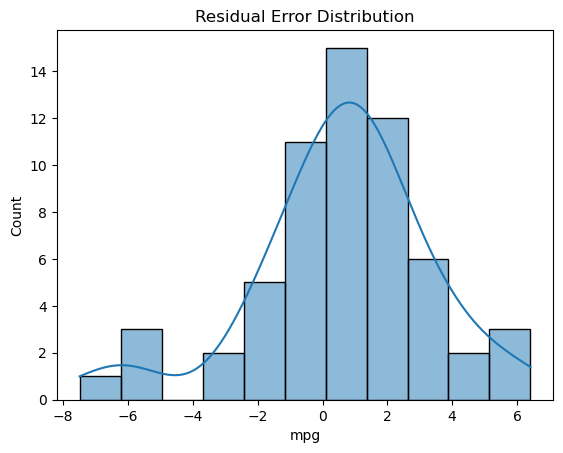

In [44]:
sns.histplot(residuals, kde=True)

plt.title("Residual Error Distribution")

plt.show()

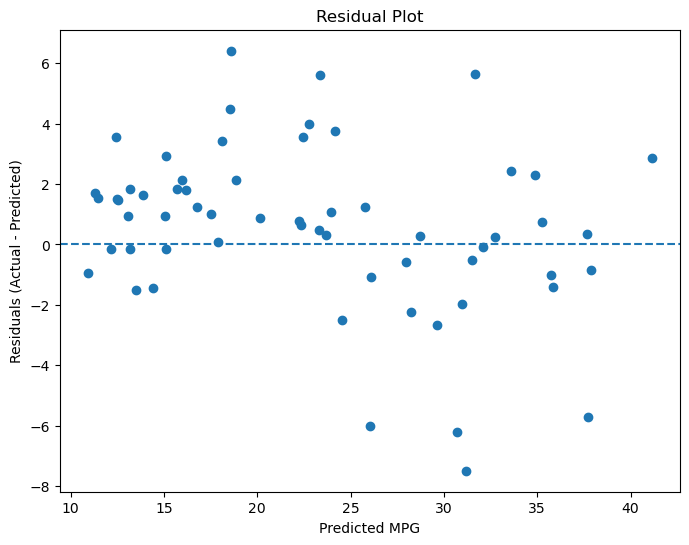

In [53]:
# Calculate residuals
residuals = y_test - y_pred.flatten()

# Residual Plot
plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted MPG")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")

plt.show()

In [45]:
print(X.columns)

Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model year', 'origin'],
      dtype='object')


In [46]:
sample_car = [[
    4,
    140,
    90,
    2400,
    15,
    82,
    1
]]

In [47]:
sample_car_scaled = scaler.transform(sample_car)

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [48]:
predicted_mpg = model.predict(sample_car_scaled)

print("Predicted MPG:", predicted_mpg[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted MPG: 30.862967


In [49]:
model.save("auto_mpg_ann_model.h5")

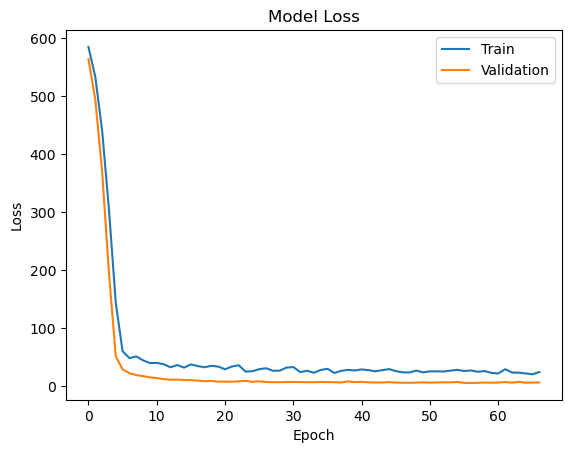

In [50]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.savefig('loss_graph.png')

plt.show()

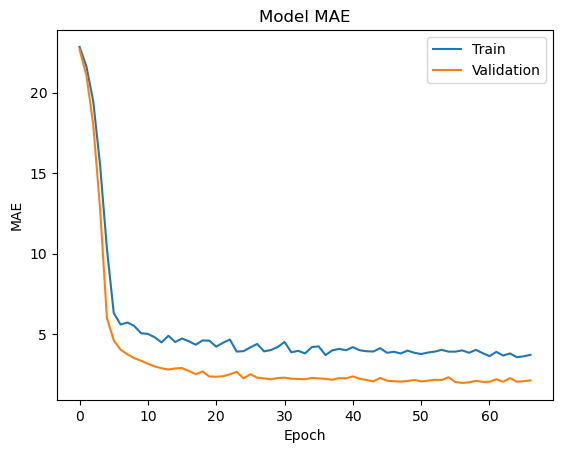

In [51]:
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])

plt.title('Model MAE')

plt.xlabel('Epoch')
plt.ylabel('MAE')

plt.legend(['Train', 'Validation'])

plt.savefig('mae_graph.png')

plt.show()

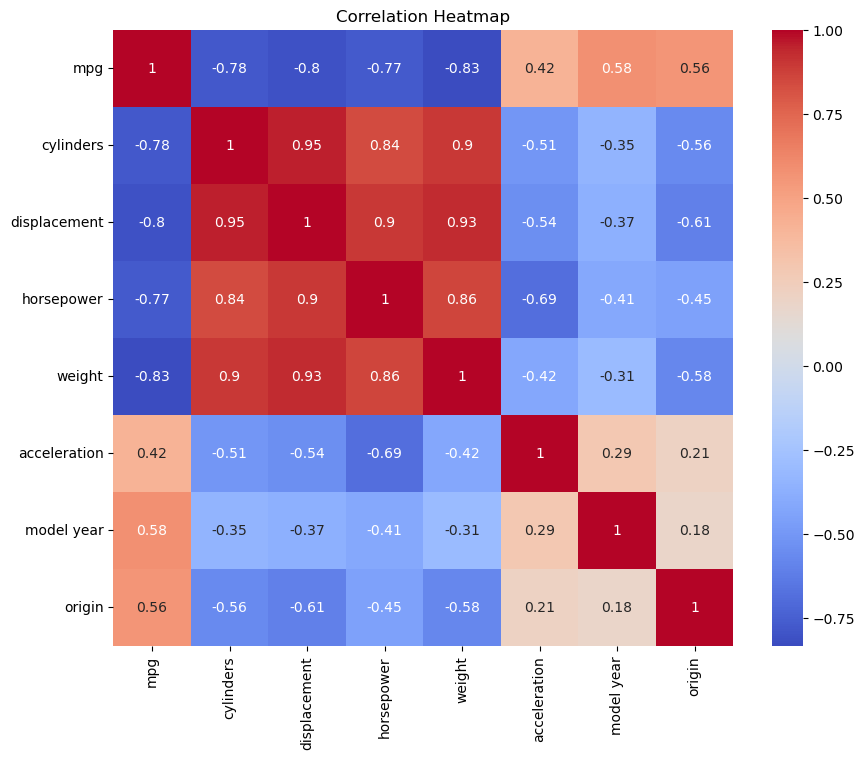

In [52]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.savefig('heatmap.png')

plt.show()